In [5]:
import numpy as np
import time
from matplotlib import pyplot as plt

In [1]:
powermeter.set_activity_state('Power', True)

In [1]:
print(f"Power: {powermeter.get_process_value('Power')*1e6:.2f} uW")

Power: 0.01 uW


In [53]:
min_output_powers = [101.53, 102.11, 91.87, 83.90, 74.88, 75.56, 66.48, 54.74, 48.95, 45.14, 46.91, 44.28, 41.75, 47.96, 48.59]  # in nw
max_output_powers = [189.84, 186.71, 151.16, 138.09, 115.78, 95.21, 79.88, 69.86, 51.49, 36.55, 22.70, 11.41, 5.56, 3.51, 0.05]  # in uw
input_powers = [6.13, 7.85, 6.43, 5.86, 4.99, 4.10, 3.47, 2.98, 2.18, 1.57, 0.95, 0.49, 0.24, 0.15, 0.091]  # in mw

In [15]:
def aom_measurement():
    switchlogic.set_state('flip_powermeter', 'in')
    switchlogic.set_state('AOM_620_2', 'on')
    AOLogic.set_setpoint('AOM_620_2_power', 0) 
    time.sleep(2)
    min_output_power = powermeter.get_process_value('Power')*1e9

    AOLogic.set_setpoint('AOM_620_2_power', 0.5) 
    time.sleep(2)
    max_output_power = powermeter.get_process_value('Power')*1e6
    return min_output_power, max_output_power
    

In [56]:
curr_min_output_power,  curr_max_output_power = aom_measurement()
# min_output_powers.append(curr_min_output_power)
# max_output_powers.append(curr_max_output_power)

In [57]:
print(curr_max_output_power, curr_min_output_power)

0.046672540000000005 46.625768


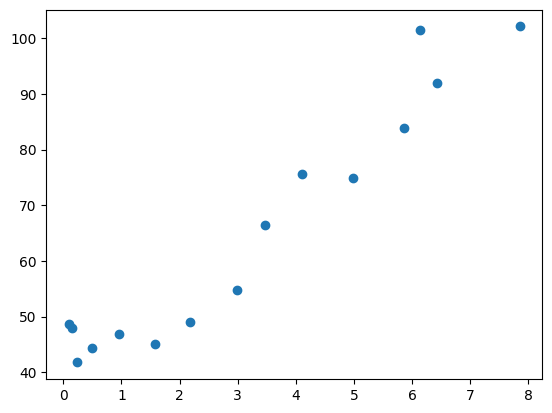

In [55]:
np_min = np.array(min_output_powers)
np_max = np.array(max_output_powers)
np_input = np.array(input_powers)
plt.scatter(np_input, np_min)

In [36]:
min_output_powers_double=[392.82, 369.60, 361.38, 392.44, 393.05, 395.01, 339.36, 388.64] #in nw
max_output_powers_double=[202.66, 165.45, 143.43, 119.63, 101.02, 82.58, 61.94, 41.01] #in uw
input_powers_double=[10.88, 8.99, 7.91, 6.38, 5.45, 4.48, 3.40, 2.39] #in mw

In [13]:
def double_aom_measurement():
    switchlogic.set_state('flip_powermeter', 'in')
    switchlogic.set_state('AOM_620_2', 'on')
    AOLogic.set_setpoint('AOM_620_2_power', 0) 
    switchlogic.set_state('AOM_620', 'on')
    AOLogic.set_setpoint('AOM_620_power', 0)
    time.sleep(2)
    min_output_power = powermeter.get_process_value('Power')*1e9

    AOLogic.set_setpoint('AOM_620_2_power', 0.5) 
    AOLogic.set_setpoint('AOM_620_power', 0.5)
    time.sleep(2)
    max_output_power = powermeter.get_process_value('Power')*1e6
    return min_output_power, max_output_power

In [32]:
curr_min_output_power,  curr_max_output_power = double_aom_measurement()

In [33]:
print(curr_max_output_power, curr_min_output_power)

41.007256999999996 388.64002


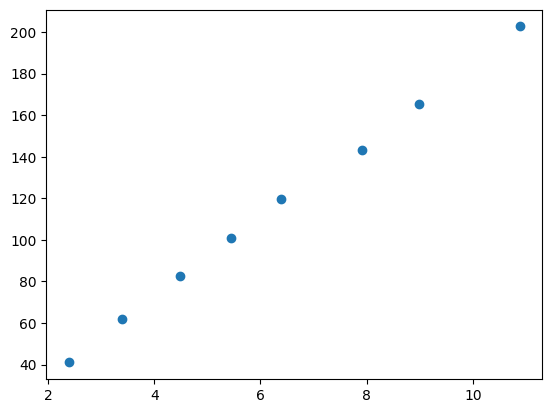

In [40]:
np_min_double=np.array(min_output_powers_double)
np_input_double=np.array(input_powers_double)
np_max_double=np.array(max_output_powers_double)
plt.scatter(np_input_double, np_max_double)
#plt.scatter(np_input_double, np_min_double)


In [1]:
abs(484.02168e12 - 484.02208e12) * 1e-6

400.0

In [2]:
abs(484.02168e12 - 484.02207e12) * 1e-6

390.0